# 🌲 Random Forest

# 1. What is Random Forest?

* Random Forest is a supervised machine-learning algorithm that combines many Decision Trees to make a prediction.

#### Instead of depending on one decision tree:

### For example, suppose we want to predict whether a customer will buy a product.

#### Three trees might predict:

* Tree 1 → Buy
* Tree 2 → Don't Buy
* Tree 3 → Buy
* Tree 4 → Buy
* Tree 5 → Buy

### Random Forest uses majority voting:

* Buy = 4
* Don't Buy = 1

### Final Prediction = Buy

##### For regression, the trees' numerical predictions are generally averaged.

## 2. Why is it called Random Forest?

* There are two important ideas:

### Random

* Each tree gets some randomness in:

* training samples
* features considered for splitting
* Forest

#### A collection of many decision trees is called a forest.

## So:

## There are also related ensemble methods such as:

* Extra Trees
* Randomized tree ensembles
* Balanced Random Forest
* Extremely randomized forests

### For normal machine-learning projects, the two most important are Classifier and Regressor.

# 5. Random Forest Classifier

* Use it when your target is a category/class.

## Examples:



# 6. Random Forest Regressor

* Use it when the target is a continuous numerical value.

# Examples:



# 7. Important Random Forest Parameters
* n_estimators

#### Number of trees.

* RandomForestClassifier(n_estimators=100)

## Means:

* 100 Decision Trees

### More trees can improve stability, but increase computation.

### max_depth

* Maximum depth of each tree.

### RandomForestClassifier(max_depth=5)

* Controls how deep trees can grow.

### min_samples_split

* Minimum number of samples required to split a node.

* min_samples_split=5
* min_samples_leaf

### Minimum number of samples that must remain in a leaf.

* min_samples_leaf=2
* max_features

#### Number of features considered when looking for a split.

* max_features="sqrt"

* This randomness is an important part of Random Forest.

### random_state

* Makes your experiment reproducible.

* random_state=42

# 8. Complete Random Forest Project Architecture

* A typical project can follow this structure:

# 9. Step 1 — Problem Understanding

* Before writing code, identify:

# 10. Step 2 — Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

| Library    | Purpose                   |
| ---------- | ------------------------- |
| pandas     | Data handling             |
| numpy      | Numerical operations      |
| matplotlib | Visualization             |
| seaborn    | Statistical visualization |
| sklearn    | Machine learning          |


# 11. Step 3 — Load Dataset

* Suppose we have:

* df = pd.read_csv("customer_data.csv")

## Check data:

* print(df.head())

# 12. Step 4 — Understand Dataset

* print(df.shape)

### Example:

(1000, 5)

#### Means:

1000 rows
5 columns

#### Check columns:

* print(df.columns)

#### Check data types:

* print(df.dtypes)

### Check missing values:

* print(df.isnull().sum())

#### Statistical summary:

* print(df.describe())

# 13. Step 5 — Example Dataset

* For learning, let's create our own dataset.

In [22]:
data = {
    "Age": [22, 25, 28, 35, 40, 45, 50, 23, 30, 38,
            42, 48, 27, 33, 52, 29, 36, 41, 24, 55],

    "Income": [25000, 30000, 35000, 50000, 60000,
               70000, 80000, 28000, 45000, 55000,
               65000, 75000, 32000, 48000, 90000,
               40000, 52000, 68000, 27000, 95000],

    "Website_Visits": [2, 3, 4, 7, 8, 10, 12, 3, 6, 7,
                       9, 11, 4, 6, 13, 5, 8, 10, 2, 14],

    "Previous_Purchases": [0, 1, 1, 3, 4, 5, 6, 1, 2, 3,
                           4, 5, 1, 2, 7, 2, 4, 5, 0, 8],

    "Purchased": [0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
                  1, 1, 0, 1, 1, 0, 1, 1, 0, 1]
}

df = pd.DataFrame(data)

print(df.head())

   Age  Income  Website_Visits  Previous_Purchases  Purchased
0   22   25000               2                   0          0
1   25   30000               3                   1          0
2   28   35000               4                   1          0
3   35   50000               7                   3          1
4   40   60000               8                   4          1


# 14. Step 6 — EDA

* Check basic information:

In [25]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age                 20 non-null     int64
 1   Income              20 non-null     int64
 2   Website_Visits      20 non-null     int64
 3   Previous_Purchases  20 non-null     int64
 4   Purchased           20 non-null     int64
dtypes: int64(5)
memory usage: 932.0 bytes
None


# Statistics:

In [28]:
print(df.describe())

             Age        Income  Website_Visits  Previous_Purchases  Purchased
count  20.000000     20.000000       20.000000           20.000000   20.00000
mean   36.150000  53500.000000        7.200000            3.200000    0.65000
std    10.230373  21397.245273        3.664912            2.307881    0.48936
min    22.000000  25000.000000        2.000000            0.000000    0.00000
25%    27.750000  34250.000000        4.000000            1.000000    0.00000
50%    35.500000  51000.000000        7.000000            3.000000    1.00000
75%    42.750000  68500.000000       10.000000            5.000000    1.00000
max    55.000000  95000.000000       14.000000            8.000000    1.00000


# Target distribution:

In [31]:
print(df["Purchased"].value_counts())

Purchased
1    13
0     7
Name: count, dtype: int64


# You can visualize it:

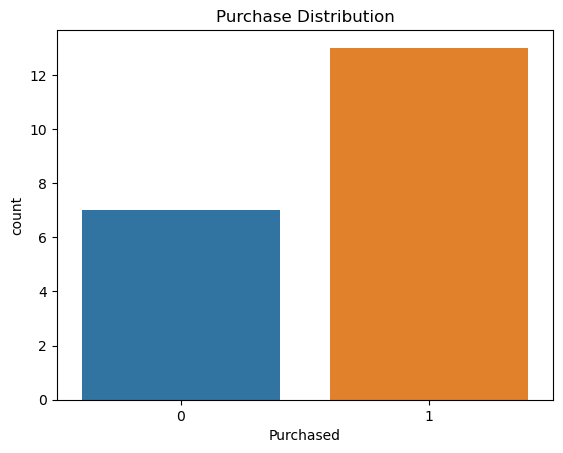

In [34]:
sns.countplot(x="Purchased", data=df)

plt.title("Purchase Distribution")
plt.show()

# This helps us understand whether the target classes are balanced.

# 15. Step 7 — Visualization
* Age vs Purchase

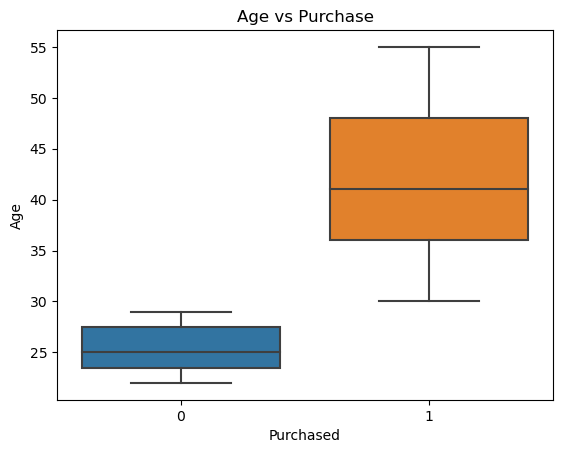

In [38]:
sns.boxplot(x="Purchased", y="Age", data=df)

plt.title("Age vs Purchase")
plt.show()

# Income vs Purchase

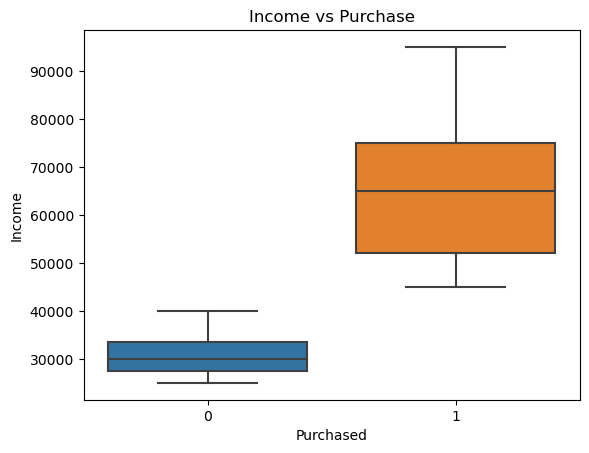

In [41]:
sns.boxplot(x="Purchased", y="Income", data=df)

plt.title("Income vs Purchase")
plt.show()

# Website Visits vs Purchase

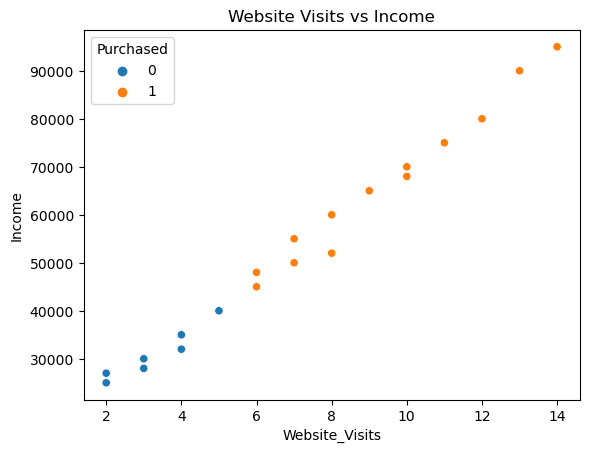

In [44]:
sns.scatterplot(
    x="Website_Visits",
    y="Income",
    hue="Purchased",
    data=df
)

plt.title("Website Visits vs Income")
plt.show()

# These visualizations help us understand relationships between features and target.

# 16. Step 8 — X and y Separation

In [48]:
X = df.drop("Purchased", axis=1)

y = df["Purchased"]

# 17. Step 9 — Train/Test Split

* This is extremely important.

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 18. Step 10 — Build Random Forest

In [54]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# 19. Step 11 — Train Model

In [57]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# 20. Step 12 — Make Predictions

In [60]:
y_pred = model.predict(X_test)

print(y_pred)

[0 1 0 0]


# 21. Step 13 — Accuracy

In [63]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


# Accuracy tells us the proportion of predictions that were correct.

# 22. Step 14 — Confusion Matrix

In [69]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3 0]
 [0 1]]


# Visualize:

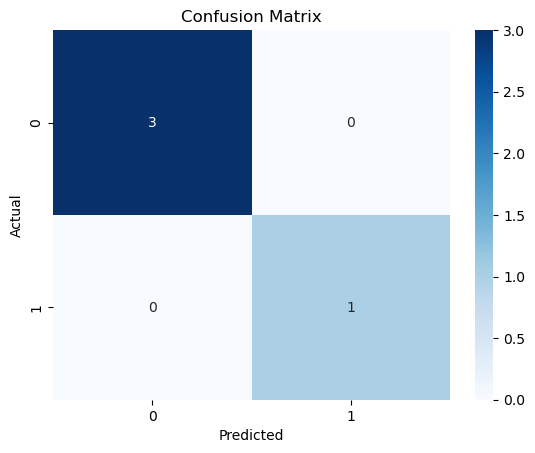

In [72]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 23. Step 15 — Classification Report

In [75]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



# 24. Step 16 — Feature Importance

* One of the useful advantages of Random Forest is that we can inspect feature importance.

In [78]:
importance = model.feature_importances_

feature_names = X.columns

for feature, value in zip(feature_names, importance):
    print(feature, value)

Age 0.25
Income 0.29
Website_Visits 0.24
Previous_Purchases 0.22


# You can visualize it:

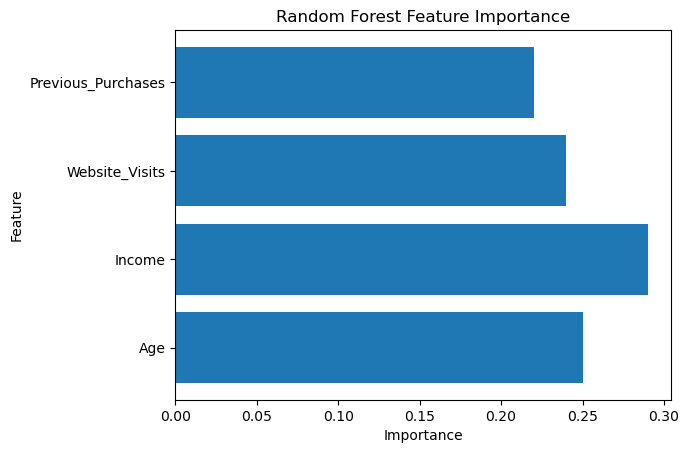

In [81]:
plt.barh(feature_names, importance)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

# complete code 

# 26. Example 1 — Customer Purchase Prediction
* Problem

#### An e-commerce company wants to predict whether a customer will purchase a product.

#### Features:

* Age
* Income
* Website Visits
* Previous Purchases

### Target:

* Purchased

### Type:

* Classification

### Model:

* RandomForestClassifier()

# 27. Example 2 — Student Pass/Fail Prediction
### Problem

* A school wants to predict whether a student will pass an exam.

### Dataset:

In [86]:
data = {
    "Study_Hours": [2, 3, 5, 6, 8, 1, 4, 7, 9, 3],
    "Attendance": [60, 65, 75, 80, 95, 50, 70, 90, 98, 68],
    "Previous_Score": [45, 50, 65, 70, 85, 40, 60, 80, 90, 55],
    "Passed": [0, 0, 1, 1, 1, 0, 1, 1, 1, 0]
}

df = pd.DataFrame(data)

# Create X/y:

In [91]:
X = df.drop("Passed", axis=1)

y = df["Passed"]

# Split:

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Build model:

In [97]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train:

In [100]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# Predict:

In [103]:
y_pred = model.predict(X_test)

# Evaluate:

In [106]:
print(accuracy_score(y_test, y_pred))

1.0


# 28. Example 3 — House Price Prediction

* Now let's use Random Forest Regression.

### Problem

* A real-estate company wants to predict house prices.

#### Features:

* Area
* Bedrooms
* Bathrooms
* Age

# Target:

* Price

### Because price is numerical, use:

* RandomForestRegressor

In [109]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

data = {
    "Area": [800, 1000, 1200, 1500, 1800, 2000,
             2200, 2500, 2800, 3000],

    "Bedrooms": [2, 2, 3, 3, 3, 4, 4, 4, 5, 5],

    "Bathrooms": [1, 2, 2, 2, 3, 3, 3, 4, 4, 4],

    "Age": [20, 15, 12, 10, 8, 6, 5, 4, 3, 2],

    "Price": [40, 50, 60, 75, 90, 110, 125, 145, 170, 190]
}

df = pd.DataFrame(data)

X = df.drop("Price", axis=1)

y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predicted:", y_pred)

print("MAE:",
      mean_absolute_error(y_test, y_pred))

print("MSE:",
      mean_squared_error(y_test, y_pred))

print("R2:",
      r2_score(y_test, y_pred))

Predicted: [173.15  54.95]
MAE: 4.050000000000004
MSE: 17.212500000000034
R2: 0.99521875


# 29. Regression Visualization

* Actual vs predicted:

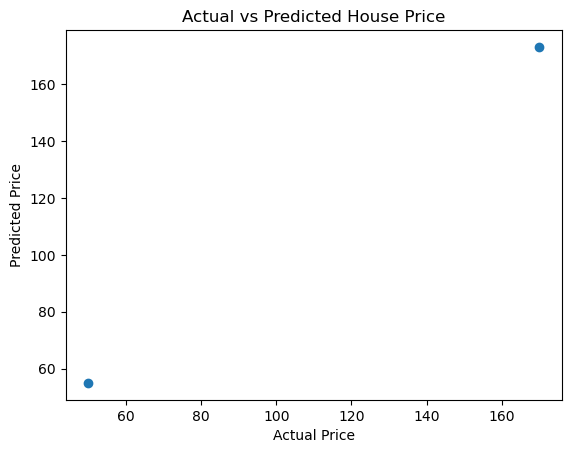

In [113]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")

plt.show()

In [115]:
# deally, predictions should be reasonably close to the actual values.

# 30. Example 4 — Employee Salary Prediction
* Problem

* A company wants to estimate employee salary.

## Features:

* Experience
* Age
* Education_Level
* Projects

## Target:

* Salary

## This is:

* Regression

###  Use:

* RandomForestRegressor

In [119]:
data = {
    "Experience": [1, 2, 3, 5, 7, 10, 12, 15, 18, 20],
    "Age": [22, 24, 26, 29, 32, 35, 38, 42, 45, 48],
    "Projects": [1, 2, 3, 5, 7, 8, 10, 12, 14, 16],
    "Salary": [25000, 30000, 35000, 45000, 60000,
               80000, 95000, 120000, 140000, 160000]
}

df = pd.DataFrame(data)

In [121]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

In [123]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [125]:
print("MAE:",
      mean_absolute_error(y_test, y_pred))

print("R2:",
      r2_score(y_test, y_pred))

MAE: 4.050000000000004
R2: 0.99521875


# 31. Example 5 — Diabetes Classification

* A common practice problem is predicting whether a patient belongs to a diabetes class based on numerical and categorical health-related features.

### Example features:

* Age
* BMI
* HbA1c_Level
* Blood_Glucose_Level
* Hypertension
* Heart_Disease
* Smoking_History

## Target:

* Diabetes

## This is a:

* Classification problem

## The basic workflow:

In [196]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

df = pd.read_csv("diabetes_prediction_dataset.csv")



In [198]:
print(df.head())


   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


In [200]:
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
None


In [202]:
print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


# If categorical variables exist, encode them:

In [205]:
df = pd.get_dummies(
    df,
    columns=["gender", "smoking_history"],
    drop_first=True,
    dtype=int
)

In [207]:
df.columns

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes', 'gender_Male', 'gender_Other',
       'smoking_history_current', 'smoking_history_ever',
       'smoking_history_former', 'smoking_history_never',
       'smoking_history_not current'],
      dtype='object')

# Separate X/y:

In [209]:
X = df.drop("diabetes", axis=1)

y = df["diabetes"]

# Split:

In [212]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create model:

In [215]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train:



In [218]:
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

# Predict:



In [220]:
y_pred = model.predict(X_test)



# Evaluate:



In [222]:
print("Accuracy:",
      accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))



SyntaxError: invalid syntax (744249582.py, line 6)

# Confusion matrix:



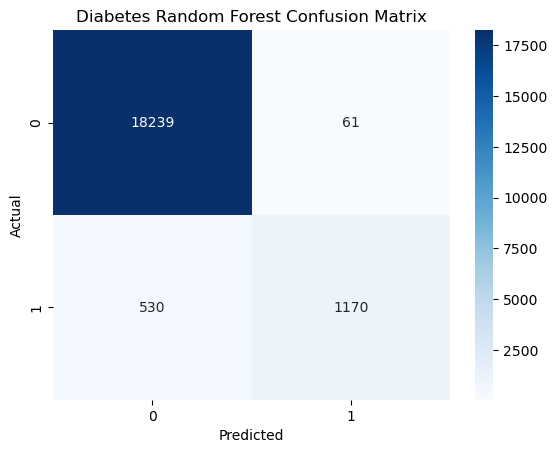

In [226]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Diabetes Random Forest Confusion Matrix")

plt.show()

# 32. Does Random Forest Need Feature Scaling?



# 33. Handling Categorical Data

* Random Forest in scikit-learn generally requires numerical input.

## Suppose:

* Gender
* Male
* Female

## You can use one-hot encoding:



# 34. Handling Missing Values

# 35. Hyperparameter Tuning

* Instead of simply:

* RandomForestClassifier(n_estimators=100)

## we can search for useful parameter combinations.

* from sklearn.model_selection import GridSearchCV

* params = {
*     "n_estimators": [50, 100, 200],
*     "max_depth": [None, 5, 10],
*     "min_samples_split": [2, 5],
*     "min_samples_leaf": [1, 2]
* }

# Create GridSearch:

* grid = GridSearchCV(
*     RandomForestClassifier(random_state=42),
*     param_grid=params,
*     cv=5,
*     scoring="accuracy"
* )

# Train:

* grid.fit(X_train, y_train)

# Best parameters:

* print(grid.best_params_)

# Best model:

* best_model = grid.best_estimator_

# Prediction:

* y_pred = best_model.predict(X_test)

# 36. Cross Validation

* Instead of relying on only one train/test split, use cross-validation.

# 37. Random Forest + Feature Importance

* Let's make a clean feature-importance chart:

# This can be useful for understanding which variables the fitted forest relied on most for its splits.

# 38. Saving Random Forest Model

* Once the model is ready:

In [236]:
import joblib

joblib.dump(model, "random_forest_model.pkl")

['random_forest_model.pkl']

# Load it later:

In [239]:
model = joblib.load(
    "random_forest_model.pkl"
)

# Then:

* prediction = model.predict(new_data)

# 39. Making Prediction for a New Customer

* Suppose:

* Age = 35
* Income = 55000
* Website Visits = 8
* Previous Purchases = 3

# Create:

In [247]:
# new_customer = pd.DataFrame({
#     "Age": [35],
#     "Income": [55000],
#     "Website_Visits": [8],
#     "Previous_Purchases": [3]
# })

# Probability:

* probability = model.predict_proba(new_customer)

* print(probability)

# You may get something conceptually like:

* [[0.15, 0.85]]

# Meaning the model assigns approximately:

* Class 0 → 15%
* Class 1 → 85%

# 40. Random Forest Complete Workflow — What and Why?

| Step | What we do            | Why                          |
| ---- | --------------------- | ---------------------------- |
| 1    | Problem Understanding | Define ML problem            |
| 2    | Load Dataset          | Get data                     |
| 3    | `head()`              | See records                  |
| 4    | `shape`               | Understand size              |
| 5    | `info()`              | Check data types             |
| 6    | Missing-value check   | Find incomplete data         |
| 7    | EDA                   | Understand patterns          |
| 8    | Visualization         | See relationships            |
| 9    | Cleaning              | Improve data quality         |
| 10   | Encoding              | Convert categories           |
| 11   | X/y separation        | Define inputs and target     |
| 12   | Train/test split      | Create unseen test data      |
| 13   | Build RF              | Create ensemble model        |
| 14   | Train                 | Learn patterns               |
| 15   | Predict               | Generate outputs             |
| 16   | Evaluate              | Measure performance          |
| 17   | Feature importance    | Inspect feature contribution |
| 18   | Cross-validation      | Check stability              |
| 19   | Hyperparameter tuning | Search model settings        |
| 20   | Save model            | Reuse trained model          |
| 21   | Deployment            | Use model in an application  |


# 41. The Most Important Random Forest Concepts to Practice

* I recommend learning these in this order: